In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # so Python can find phast_bootstrap.py
import phast_bootstrap

[phast_bootstrap] ready. Colab paths now resolve under: C:\Users\Swara Deshpande\exoplanet-detection-isro


In [3]:
from google.colab import drive

drive.mount('/content/drive')

[pipeline] mock drive.mount — using local repo


In [4]:
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import least_squares

In [5]:
DATA_DIR = "/content/drive/MyDrive/exoplanet_pipeline/data"

stage1_path = os.path.join(
    DATA_DIR,
    "stage1_output.pkl"
)

stage2_path = os.path.join(
    DATA_DIR,
    "stage2_output.pkl"
)

stage3_path = os.path.join(
    DATA_DIR,
    "stage3_output.pkl"
)

os.makedirs(DATA_DIR, exist_ok=True)

print("Stage 1:", stage1_path)
print("Stage 2:", stage2_path)
print("Stage 3:", stage3_path)

Stage 1: /content/drive/MyDrive/exoplanet_pipeline/data\stage1_output.pkl
Stage 2: /content/drive/MyDrive/exoplanet_pipeline/data\stage2_output.pkl
Stage 3: /content/drive/MyDrive/exoplanet_pipeline/data\stage3_output.pkl


In [6]:
PREFILTER_CONFIG = {
    # Reject if transit depth is greater than 5%
    "max_depth": 0.05,

    # Secondary eclipse configuration
    "secondary_ratio_threshold": 0.20,
    "secondary_snr_threshold": 3.0,

    # Odd/even configuration
    "odd_even_sigma_threshold": 3.0,
    "minimum_transits_per_group": 2,
    "minimum_points_per_transit": 3,

    # Transit-shape configuration
    "minimum_flat_fraction": 0.10,
    "minimum_shape_snr": 5.0,

    # Keep False initially because real grazing planets
    # can also appear V-shaped.
    "vshape_as_hard_rejection": True
}

print(PREFILTER_CONFIG)

{'max_depth': 0.05, 'secondary_ratio_threshold': 0.2, 'secondary_snr_threshold': 3.0, 'odd_even_sigma_threshold': 3.0, 'minimum_transits_per_group': 2, 'minimum_points_per_transit': 3, 'minimum_flat_fraction': 0.1, 'minimum_shape_snr': 5.0, 'vshape_as_hard_rejection': True}


In [7]:
with open(stage1_path, "rb") as f:
    stage1_data = pickle.load(f)

print(stage1_data.keys())

with open(stage2_path, "rb") as f:
    stage2_data = pickle.load(f)

print(stage2_data.keys())

dict_keys(['time', 'flux', 'flux_err', 'tic_id', 'crowdsap', 'ra', 'dec', 'sector'])
dict_keys(['period', 'sde', 'duration', 't0', 'depth_tls', 'snr_tls', 'distinct_transit_count', 'odd_even_mismatch_tls'])


In [8]:
time = np.asarray(
    stage1_data["time"],
    dtype=float
)

flux = np.asarray(
    stage1_data["flux"],
    dtype=float
)

flux_err = np.asarray(
    stage1_data["flux_err"],
    dtype=float
)

period = float(stage2_data["period"])
duration = float(stage2_data["duration"])
t0 = float(stage2_data["t0"])
sde = float(stage2_data["sde"])

print("Period:", period)
print("Duration:", duration)
print("T0:", t0)
print("SDE:", sde)
print("Number of cadences:", len(time))

Period: 6.267090136076321
Duration: 0.12476139841324797
T0: 0.20952101445453392
SDE: 17.69836307589993
Number of cadences: 18261


In [9]:
valid = (
    np.isfinite(time)
    & np.isfinite(flux)
    & np.isfinite(flux_err)
)

time = time[valid]
flux = flux[valid]
flux_err = flux_err[valid]

# Stage 2 used the same shifted time.
time_tls = time - np.min(time)

print("Valid cadences:", len(time_tls))
print("Time minimum:", time_tls.min())
print("Time maximum:", time_tls.max())

Valid cadences: 18261
Time minimum: 0.0
Time maximum: 27.880105402320623


In [10]:
median_flux = np.nanmedian(flux)

if -0.20 < median_flux < 0.20:
    flux_normalized = flux + 1.0
    flux_err_normalized = flux_err.copy()

    normalization_mode = "added 1.0"

else:
    flux_normalized = flux / median_flux

    flux_err_normalized = (
        flux_err / abs(median_flux)
    )

    normalization_mode = "divided by median"

print("Original median:", median_flux)
print(
    "Normalized median:",
    np.nanmedian(flux_normalized)
)
print("Normalization:", normalization_mode)

Original median: 0.0
Normalized median: 1.0
Normalization: added 1.0


In [11]:
phase = (
    ((time_tls - t0) % period)
    / period
)

duration_phase = duration / period

distance_from_primary = np.minimum(
    phase,
    1.0 - phase
)

distance_from_secondary = np.abs(
    phase - 0.5
)

primary_mask = (
    distance_from_primary
    <= duration_phase / 2.0
)

secondary_mask = (
    distance_from_secondary
    <= duration_phase / 2.0
)

out_of_eclipse_mask = (
    (
        distance_from_primary
        > 1.5 * duration_phase
    )
    &
    (
        distance_from_secondary
        > 1.5 * duration_phase
    )
)

print(
    "Primary transit points:",
    np.sum(primary_mask)
)

print(
    "Secondary eclipse points:",
    np.sum(secondary_mask)
)

print(
    "Out-of-eclipse points:",
    np.sum(out_of_eclipse_mask)
)

Primary transit points: 442
Secondary eclipse points: 332
Out-of-eclipse points: 15909


In [12]:
def robust_median_error(values):
    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) < 2:
        return np.nan

    median = np.nanmedian(values)

    mad = np.nanmedian(
        np.abs(values - median)
    )

    sigma = 1.4826 * mad

    if (
        not np.isfinite(sigma)
        or sigma == 0
    ):
        sigma = np.nanstd(
            values,
            ddof=1
        )

    if not np.isfinite(sigma):
        return np.nan

    return (
        1.2533
        * sigma
        / np.sqrt(len(values))
    )


def standard_error(values):
    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) < 2:
        return np.nan

    return (
        np.nanstd(values, ddof=1)
        / np.sqrt(len(values))
    )

In [13]:
# Physics check 1: Transit depth

if np.sum(primary_mask) < 3:
    raise ValueError(
        "Not enough points inside the "
        "primary transit window."
    )

if np.sum(out_of_eclipse_mask) < 10:
    raise ValueError(
        "Not enough out-of-eclipse points "
        "to calculate the baseline."
    )

baseline_flux = np.nanmedian(
    flux_normalized[out_of_eclipse_mask]
)

primary_flux = np.nanmedian(
    flux_normalized[primary_mask]
)

baseline_error = robust_median_error(
    flux_normalized[out_of_eclipse_mask]
)

primary_error = robust_median_error(
    flux_normalized[primary_mask]
)

primary_depth = (
    baseline_flux - primary_flux
) / baseline_flux

primary_depth_error = np.sqrt(
    baseline_error**2
    + primary_error**2
) / abs(baseline_flux)

if (
    np.isfinite(primary_depth_error)
    and primary_depth_error > 0
):
    primary_snr = (
        primary_depth
        / primary_depth_error
    )
else:
    primary_snr = np.nan

depth_rejected = (
    primary_depth
    > PREFILTER_CONFIG["max_depth"]
)

print("Baseline flux:", baseline_flux)
print("Primary flux:", primary_flux)
print("Primary depth:", primary_depth)
print("Primary SNR:", primary_snr)
print("Depth rejected:", depth_rejected)

Baseline flux: 1.0000018776428892
Primary flux: 0.9997475423788267
Primary depth: 0.00025433478651258514
Primary SNR: 33.959393948045175
Depth rejected: False


In [14]:
# Physics check 2: Secondary eclipse

if np.sum(secondary_mask) >= 3:
    secondary_flux = np.nanmedian(
        flux_normalized[secondary_mask]
    )

    secondary_error = robust_median_error(
        flux_normalized[secondary_mask]
    )

    secondary_depth = (
        baseline_flux - secondary_flux
    ) / baseline_flux

    secondary_depth_error = np.sqrt(
        baseline_error**2
        + secondary_error**2
    ) / abs(baseline_flux)

    if (
        np.isfinite(secondary_depth_error)
        and secondary_depth_error > 0
    ):
        secondary_snr = (
            secondary_depth
            / secondary_depth_error
        )
    else:
        secondary_snr = np.nan

else:
    secondary_flux = np.nan
    secondary_depth = np.nan
    secondary_depth_error = np.nan
    secondary_snr = np.nan

In [15]:
# Apply secondary eclipse rule
if (
    primary_depth > 0
    and np.isfinite(secondary_depth)
):
    secondary_ratio = (
        secondary_depth
        / primary_depth
    )
else:
    secondary_ratio = np.nan

secondary_rejected = (
    np.isfinite(secondary_ratio)
    and np.isfinite(secondary_snr)

    and secondary_ratio
        > PREFILTER_CONFIG[
            "secondary_ratio_threshold"
        ]

    and secondary_snr
        > PREFILTER_CONFIG[
            "secondary_snr_threshold"
        ]
)

print("Secondary depth:", secondary_depth)

print(
    "Secondary / primary ratio:",
    secondary_ratio
)

print("Secondary SNR:", secondary_snr)

print(
    "Secondary rejected:",
    secondary_rejected
)

Secondary depth: -1.2972781056984386e-05
Secondary / primary ratio: -0.05100671140926473
Secondary SNR: -1.351517752582694
Secondary rejected: False


In [16]:
# Physics check 3: Odd/even mismatch

transit_number = np.rint(
    (time_tls - t0) / period
).astype(int)

nearest_transit_time = (
    t0
    + transit_number * period
)

distance_from_transit = (
    time_tls
    - nearest_transit_time
)

event_mask = (
    np.abs(distance_from_transit)
    <= duration / 2.0
)

event_numbers = []
event_depths = []

for number in np.unique(
    transit_number[event_mask]
):
    current_mask = (
        event_mask
        & (transit_number == number)
    )

    if (
        np.sum(current_mask)
        < PREFILTER_CONFIG[
            "minimum_points_per_transit"
        ]
    ):
        continue

    current_flux = np.nanmedian(
        flux_normalized[current_mask]
    )

    current_depth = (
        baseline_flux - current_flux
    ) / baseline_flux

    event_numbers.append(
        int(number)
    )

    event_depths.append(
        float(current_depth)
    )

event_numbers = np.asarray(
    event_numbers,
    dtype=int
)

event_depths = np.asarray(
    event_depths,
    dtype=float
)

print(
    "Measured transit events:",
    len(event_depths)
)

print("Transit numbers:", event_numbers)
print("Event depths:", event_depths)

Measured transit events: 5
Transit numbers: [0 1 2 3 4]
Event depths: [0.00024977 0.00023974 0.00023112 0.00031758 0.00023893]


In [17]:
# Seperate odd even transits

odd_depths = event_depths[
    event_numbers % 2 != 0
]

even_depths = event_depths[
    event_numbers % 2 == 0
]

enough_odd_even_data = (
    len(odd_depths)
        >= PREFILTER_CONFIG[
            "minimum_transits_per_group"
        ]

    and

    len(even_depths)
        >= PREFILTER_CONFIG[
            "minimum_transits_per_group"
        ]
)

print("Odd transits:", len(odd_depths))
print("Even transits:", len(even_depths))
print("Enough data:", enough_odd_even_data)

Odd transits: 2
Even transits: 3
Enough data: True


In [18]:
# Calculate the odd/even significance
# odd_even_sigma > 3 means the odd and even transit depths differ by more than three standard deviations.

if enough_odd_even_data:
    odd_depth = np.nanmean(
        odd_depths
    )

    even_depth = np.nanmean(
        even_depths
    )

    odd_error = standard_error(
        odd_depths
    )

    even_error = standard_error(
        even_depths
    )

    combined_error = np.sqrt(
        odd_error**2
        + even_error**2
    )

    depth_difference = abs(
        odd_depth - even_depth
    )

    if (
        np.isfinite(combined_error)
        and combined_error > 0
    ):
        odd_even_sigma = (
            depth_difference
            / combined_error
        )

    elif depth_difference > 0:
        odd_even_sigma = np.inf

    else:
        odd_even_sigma = 0.0

else:
    odd_depth = np.nan
    even_depth = np.nan

    odd_error = np.nan
    even_error = np.nan

    odd_even_sigma = np.nan

odd_even_rejected = (
    enough_odd_even_data
    and odd_even_sigma
        > PREFILTER_CONFIG[
            "odd_even_sigma_threshold"
        ]
)

print("Odd depth:", odd_depth)
print("Even depth:", even_depth)

print(
    "Odd/even difference sigma:",
    odd_even_sigma
)

print(
    "Odd/even rejected:",
    odd_even_rejected
)

Odd depth: 0.00027865875099437534
Even depth: 0.00023993955139224536
Odd/even difference sigma: 0.9854183468003194
Odd/even rejected: False


In [19]:
# Physics check 4: V-shaped transit
# The original rule used the ingress-to-egress ratio. That mainly measures asymmetry, not whether the transit is V-shaped.
# This implementation fits a trapezoid and measures:

# flat_fraction = flat-bottom duration / total duration

# A value close to zero represents a V-shaped event.

def trapezoid_model(
    x,
    baseline,
    depth,
    total_duration,
    flat_fraction,
    center
):
    distance = np.abs(
        x - center
    )

    half_total = (
        total_duration / 2.0
    )

    half_flat = (
        flat_fraction
        * half_total
    )

    model_flux = np.full_like(
        x,
        baseline,
        dtype=float
    )

    flat_mask = (
        distance <= half_flat
    )

    model_flux[flat_mask] = (
        baseline - depth
    )

    slope_mask = (
        (distance > half_flat)
        & (distance < half_total)
    )

    denominator = max(
        half_total - half_flat,
        1e-12
    )

    transit_fraction = (
        half_total
        - distance[slope_mask]
    ) / denominator

    model_flux[slope_mask] = (
        baseline
        - depth * transit_fraction
    )

    return model_flux

In [20]:
# Fit the Trapezoid

shape_window = (
    np.abs(distance_from_transit)
    <= 1.5 * duration
)

x_shape = distance_from_transit[
    shape_window
]

y_shape = flux_normalized[
    shape_window
]

minimum_duration = max(
    0.30 * duration,
    1e-6
)

maximum_duration = min(
    3.0 * duration,
    0.25 * period
)

if maximum_duration <= minimum_duration:
    maximum_duration = (
        3.0 * duration
    )

initial_depth = max(
    primary_depth,
    1e-5
)

initial_parameters = [
    baseline_flux,
    initial_depth,
    duration,
    0.50,
    0.0
]

lower_bounds = [
    0.50,
    0.0,
    minimum_duration,
    0.0,
    -0.50 * duration
]

upper_bounds = [
    1.50,
    0.90,
    maximum_duration,
    1.0,
    0.50 * duration
]

shape_fit_success = False
flat_fraction = np.nan
shape_parameters = None

In [21]:
# Run the trapezoid fit

if len(x_shape) >= 20:
    try:
        shape_fit = least_squares(
            lambda parameters:
                trapezoid_model(
                    x_shape,
                    *parameters
                ) - y_shape,

            x0=initial_parameters,

            bounds=(
                lower_bounds,
                upper_bounds
            ),

            loss="soft_l1"
        )

        shape_parameters = (
            shape_fit.x
        )

        flat_fraction = float(
            shape_parameters[3]
        )

        shape_fit_success = bool(
            shape_fit.success
        )

    except Exception as error:
        print(
            "Shape fit failed:",
            error
        )

extreme_vshape = (
    shape_fit_success

    and np.isfinite(
        flat_fraction
    )

    and flat_fraction
        < PREFILTER_CONFIG[
            "minimum_flat_fraction"
        ]

    and np.isfinite(
        primary_snr
    )

    and primary_snr
        >= PREFILTER_CONFIG[
            "minimum_shape_snr"
        ]
)

print(
    "Shape fit success:",
    shape_fit_success
)

print(
    "Flat-bottom fraction:",
    flat_fraction
)

print(
    "Extreme V-shape:",
    extreme_vshape
)

Shape fit success: True
Flat-bottom fraction: 0.8317767069210047
Extreme V-shape: False


In [22]:
flags = {
    "depth_too_large": bool(
        depth_rejected
    ),

    "secondary_eclipse": bool(
        secondary_rejected
    ),

    "odd_even_mismatch": bool(
        odd_even_rejected
    ),

    "extreme_v_shape": bool(
        extreme_vshape
    )
}

hard_rejection_flags = {
    "depth_too_large":
        flags["depth_too_large"],

    "secondary_eclipse":
        flags["secondary_eclipse"],

    "odd_even_mismatch":
        flags["odd_even_mismatch"]
}

if PREFILTER_CONFIG[
    "vshape_as_hard_rejection"
]:
    hard_rejection_flags[
        "extreme_v_shape"
    ] = flags["extreme_v_shape"]

In [23]:
rejection_reasons = [
    name
    for name, value
    in hard_rejection_flags.items()
    if value
]

warning_reasons = []

if (
    flags["extreme_v_shape"]
    and not PREFILTER_CONFIG[
        "vshape_as_hard_rejection"
    ]
):
    warning_reasons.append(
        "extreme_v_shape"
    )

if len(rejection_reasons) > 0:
    decision = "REJECTED"

elif len(warning_reasons) > 0:
    decision = "PASSED_WITH_WARNING"

else:
    decision = "PASSED"

print("Decision:", decision)

print(
    "Rejection reasons:",
    rejection_reasons
)

print(
    "Warnings:",
    warning_reasons
)

Decision: PASSED
Rejection reasons: []
Warnings: []


In [24]:
print("=" * 60)

print(
    "STAGE 3 PHYSICS PRE-FILTER RESULT"
)

print("=" * 60)

print("Decision:", decision)
print()

print(
    "Primary depth:",
    primary_depth
)

print(
    "Primary SNR:",
    primary_snr
)

print()

print(
    "Secondary ratio:",
    secondary_ratio
)

print(
    "Secondary SNR:",
    secondary_snr
)

print()

print(
    "Odd/even sigma:",
    odd_even_sigma
)

print()

print(
    "Flat-bottom fraction:",
    flat_fraction
)

print()

print("Flags:", flags)

print(
    "Rejection reasons:",
    rejection_reasons
)

print(
    "Warnings:",
    warning_reasons
)

STAGE 3 PHYSICS PRE-FILTER RESULT
Decision: PASSED

Primary depth: 0.00025433478651258514
Primary SNR: 33.959393948045175

Secondary ratio: -0.05100671140926473
Secondary SNR: -1.351517752582694

Odd/even sigma: 0.9854183468003194

Flat-bottom fraction: 0.8317767069210047

Flags: {'depth_too_large': False, 'secondary_eclipse': False, 'odd_even_mismatch': False, 'extreme_v_shape': False}
Rejection reasons: []
Warnings: []


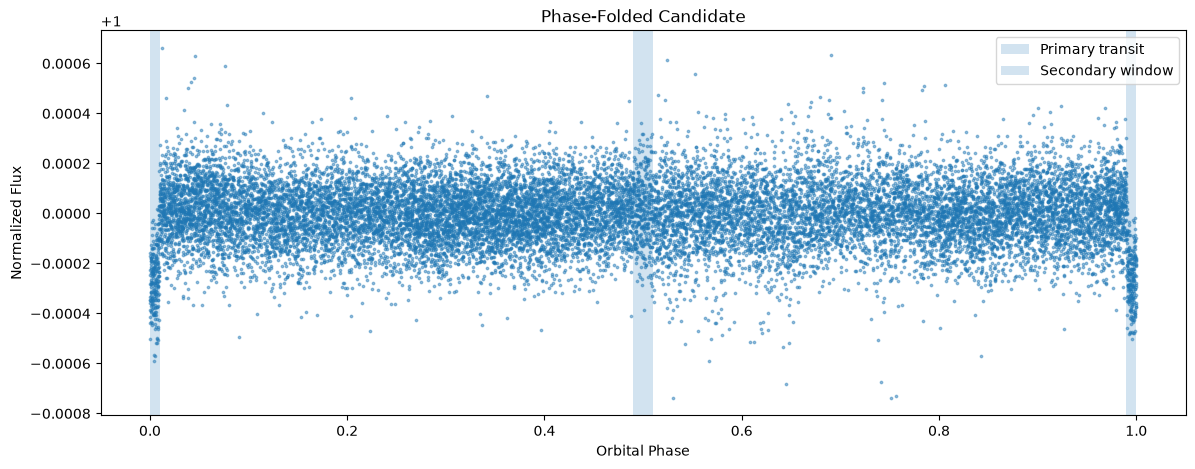

In [25]:
plt.figure(figsize=(14, 5))

plt.scatter(
    phase,
    flux_normalized,
    s=3,
    alpha=0.45
)

plt.axvspan(
    0.0,
    duration_phase / 2.0,
    alpha=0.20,
    label="Primary transit"
)

plt.axvspan(
    1.0 - duration_phase / 2.0,
    1.0,
    alpha=0.20
)

plt.axvspan(
    0.5 - duration_phase / 2.0,
    0.5 + duration_phase / 2.0,
    alpha=0.20,
    label="Secondary window"
)

plt.xlabel("Orbital Phase")
plt.ylabel("Normalized Flux")

plt.title(
    "Phase-Folded Candidate"
)

plt.legend()
plt.show()

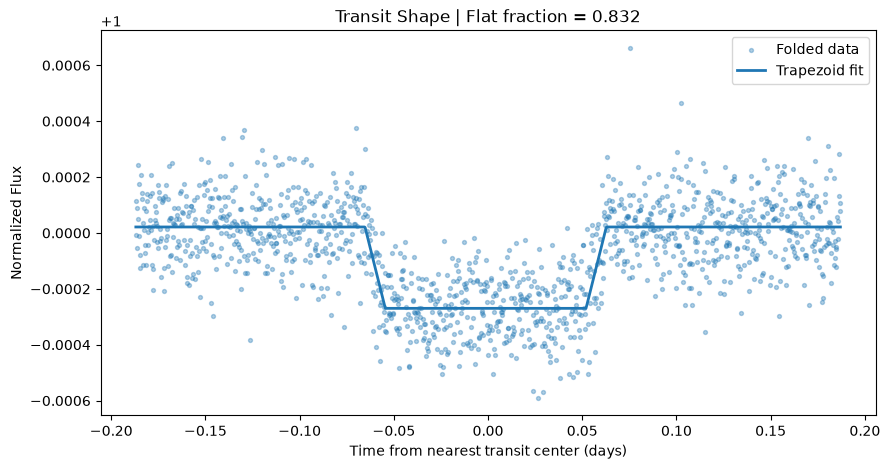

In [26]:
if shape_fit_success:
    order = np.argsort(
        x_shape
    )

    fitted_flux = trapezoid_model(
        x_shape,
        *shape_parameters
    )

    plt.figure(figsize=(10, 5))

    plt.scatter(
        x_shape,
        y_shape,
        s=8,
        alpha=0.35,
        label="Folded data"
    )

    plt.plot(
        x_shape[order],
        fitted_flux[order],
        linewidth=2,
        label="Trapezoid fit"
    )

    plt.xlabel(
        "Time from nearest "
        "transit center (days)"
    )

    plt.ylabel(
        "Normalized Flux"
    )

    plt.title(
        "Transit Shape | "
        f"Flat fraction = "
        f"{flat_fraction:.3f}"
    )

    plt.legend()
    plt.show()

else:
    print(
        "No reliable trapezoid "
        "fit to plot."
    )

In [27]:
stage3_data = {
    "candidate": {
        "period": period,
        "duration": duration,
        "t0": t0,
        "sde": sde
    },

    "metrics": {
        "primary_depth":
            float(primary_depth),

        "primary_depth_error":
            float(primary_depth_error),

        "primary_snr":
            float(primary_snr),

        "secondary_depth":
            float(secondary_depth),

        "secondary_ratio":
            float(secondary_ratio),

        "secondary_snr":
            float(secondary_snr),

        "odd_depth":
            float(odd_depth),

        "even_depth":
            float(even_depth),

        "odd_even_sigma":
            float(odd_even_sigma),

        "flat_fraction":
            float(flat_fraction)
    },

    "flags": flags,

    "decision": decision,

    "rejection_reasons":
        rejection_reasons,

    "warning_reasons":
        warning_reasons,

    "event_numbers":
        event_numbers,

    "event_depths":
        event_depths,

    "config":
        PREFILTER_CONFIG
}

print(stage3_data.keys())

dict_keys(['candidate', 'metrics', 'flags', 'decision', 'rejection_reasons', 'warning_reasons', 'event_numbers', 'event_depths', 'config'])


In [28]:
with open(stage3_path, "wb") as f:
    pickle.dump(
        stage3_data,
        f
    )

print(
    "Stage 3 data saved successfully!"
)

print(stage3_path)

Stage 3 data saved successfully!
/content/drive/MyDrive/exoplanet_pipeline/data\stage3_output.pkl


In [29]:
with open(stage3_path, "rb") as f:
    saved_stage3_data = pickle.load(f)

print(
    saved_stage3_data.keys()
)

print(
    "Decision:",
    saved_stage3_data["decision"]
)

print(
    "Flags:",
    saved_stage3_data["flags"]
)

print(
    "Metrics:",
    saved_stage3_data["metrics"]
)

dict_keys(['candidate', 'metrics', 'flags', 'decision', 'rejection_reasons', 'warning_reasons', 'event_numbers', 'event_depths', 'config'])
Decision: PASSED
Flags: {'depth_too_large': False, 'secondary_eclipse': False, 'odd_even_mismatch': False, 'extreme_v_shape': False}
Metrics: {'primary_depth': 0.00025433478651258514, 'primary_depth_error': 7.489379430672248e-06, 'primary_snr': 33.959393948045175, 'secondary_depth': -1.2972781056984386e-05, 'secondary_ratio': -0.05100671140926473, 'secondary_snr': -1.351517752582694, 'odd_depth': 0.00027865875099437534, 'even_depth': 0.00023993955139224536, 'odd_even_sigma': 0.9854183468003194, 'flat_fraction': 0.8317767069210047}
